In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3 

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns',50)
pd.set_option('display.float_format','{:.4f}'.format)

print('All imports done')


All imports done


In [3]:
path='../data/amex_train_last_statement.parquet'

df=pd.read_parquet(path)

print(f'Shape:{df.shape}')
print(f'Total Customers:{df.shape[0]:,}')
print(f'Total columns:{df.shape[1]}')

Shape:(458913, 191)
Total Customers:458,913
Total columns:191


In [4]:
print('First 5 rows:')
display(df.head())

print('\nData types:')
print(df.dtypes.value_counts())

print('\nTarget column check:')
print(df['target'].value_counts())

First 5 rows:


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,...,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2018-03-13,0.9347,0.0091,0.0094,1.0076,0.0061,0.1350,0.0016,0.0072,NaN,NaN,0.0033,0.0708,0.7401,0.2317,0.0083,0.4205,0.5397,0.1924,NaN,0.1496,0.0584,0.0029,0.1535,...,0.0084,1.0000,1.0083,0.9997,1.0085,0.0040,NaN,0.0042,0.0057,NaN,0.0062,0.0027,NaN,NaN,NaN,NaN,NaN,0.0072,0.0042,0.0051,NaN,0.0058,0.0030,0.0085,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,2018-03-25,0.8805,0.1781,0.0347,1.0040,0.0069,0.1655,0.0056,0.0051,NaN,0.0606,0.0088,0.0206,0.2663,0.0270,0.0050,0.4388,0.4022,0.0147,NaN,0.1676,0.0284,0.0010,NaN,...,0.0093,1.0000,0.0002,0.9993,0.0018,0.0029,NaN,0.0022,0.0019,NaN,0.0030,0.0017,NaN,NaN,NaN,NaN,NaN,0.0030,0.0075,0.0079,NaN,0.0033,0.0032,0.0085,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,2018-03-12,0.8809,0.0097,0.0043,0.8126,0.0064,NaN,0.0038,0.0072,NaN,NaN,0.0006,0.0310,0.2516,0.0016,0.0017,0.4337,0.3391,0.0804,NaN,0.1836,0.0270,0.0002,NaN,...,0.0047,1.0000,0.0095,0.0083,0.0042,0.0041,NaN,0.0027,0.0035,NaN,0.0099,0.0077,NaN,NaN,NaN,NaN,NaN,0.0074,0.0066,0.0010,NaN,0.0022,0.0008,0.0034,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,2018-03-29,0.6218,0.0011,0.0126,1.0062,0.0078,0.2878,0.0045,0.0099,NaN,0.0461,0.0078,0.0072,0.0851,0.1188,0.0042,0.4107,0.4142,NaN,NaN,0.1743,0.0120,1.0056,0.4303,...,0.0045,1.0000,0.0093,1.0027,1.0019,0.0043,NaN,0.0001,0.0046,NaN,0.0018,0.0051,NaN,NaN,NaN,NaN,NaN,0.0027,0.0062,0.0019,NaN,0.0082,0.0056,0.0030,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,2018-03-30,0.8719,0.0056,0.0077,0.8157,0.0012,NaN,0.0002,0.0055,NaN,0.0447,0.0024,0.2694,0.0700,0.0049,0.0020,0.4655,0.4803,0.3251,NaN,0.0489,0.1598,1.0052,0.0952,...,0.0001,1.0000,0.0072,1.0062,1.0086,0.0011,NaN,1.0061,0.0089,NaN,0.0050,0.0037,NaN,NaN,NaN,NaN,NaN,0.0030,0.0042,0.0058,NaN,0.0082,0.0069,0.0009,0



Data types:
float32    177
float64      9
object       4
int64        1
Name: count, dtype: int64

Target column check:
target
0    340085
1    118828
Name: count, dtype: int64


In [5]:
cat_cols=[
    'B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120',
            'D_126', 'D_63', 'D_64', 'D_66', 'D_68'
]
#ye 11 columns diya tha amex data dictionary

numeric_cols=[col for col in df.columns
              if col not in cat_cols + ['customer_ID','S_2','target']]

print(f'Numeric features:{len(numeric_cols)}')
print(f'Categorical features:{len(cat_cols)}')
print(f'Identifier colums: customer_ID,S_2')
print(f'Target column:target')

Numeric features:177
Categorical features:11
Identifier colums: customer_ID,S_2
Target column:target


In [6]:
conn=sqlite3.connect(':memory:')
df.to_sql('amex',conn,index=False,if_exists='replace')
print('Data loaded into SQLite successfully')

Data loaded into SQLite successfully


In [7]:
query='''
Select 
      target,
      COunt(*)as customer_count,
      Round(Count(*)*100.0/SUM(Count(*))OVER(),2) as percentage
FROM amex
Group By target
Order By target 
'''
target_dist=pd.read_sql_query(query,conn)
print('Target Distribution:')
print(target_dist)

imbalance_ratio=target_dist['customer_count'].iloc[0]/target_dist['customer_count'].iloc[1]
print(f'\nClass imbalance ratio:{imbalance_ratio:.2f}:1')

Target Distribution:
   target  customer_count  percentage
0       0          340085     74.1100
1       1          118828     25.8900

Class imbalance ratio:2.86:1


In [8]:
missing=pd.DataFrame({
    'column':df.columns,
    'missing_count':df.isnull().sum().values,
    'missing_pct':(df.isnull().sum().values/len(df))*100
})

missing=missing.sort_values('missing_pct',ascending=False).reset_index(drop=True)

print(f'Total columns:{len(missing)}')
print(f'Columns with zero missing:{(missing["missing_pct"]==0).sum()}')
print(f'Columns with >50% missing:{(missing["missing_pct"]>50).sum()}')
print(f'Columns with >80% missing:{(missing["missing_pct"]>80).sum()}')
print()
print('Top 20 columns by missing %:')
print(missing.head(20).to_string(index=False))

Total columns:191
Columns with zero missing:82
Columns with >50% missing:29
Columns with >80% missing:23

Top 20 columns by missing %:
column  missing_count  missing_pct
  D_87         458268      99.8595
  D_88         458086      99.8198
 D_108         456286      99.4276
 D_110         455235      99.1985
 D_111         455235      99.1985
  B_39         454808      99.1055
  D_73         454674      99.0763
  B_42         452771      98.6616
 D_138         442518      96.4274
 D_136         442518      96.4274
 D_135         442518      96.4274
 D_134         442518      96.4274
 D_137         442518      96.4274
   R_9         431960      94.1268
  B_29         431589      94.0459
  D_76         409597      89.2537
  R_26         407770      88.8556
 D_106         407265      88.7456
 D_132         407153      88.7212
  D_49         407150      88.7205


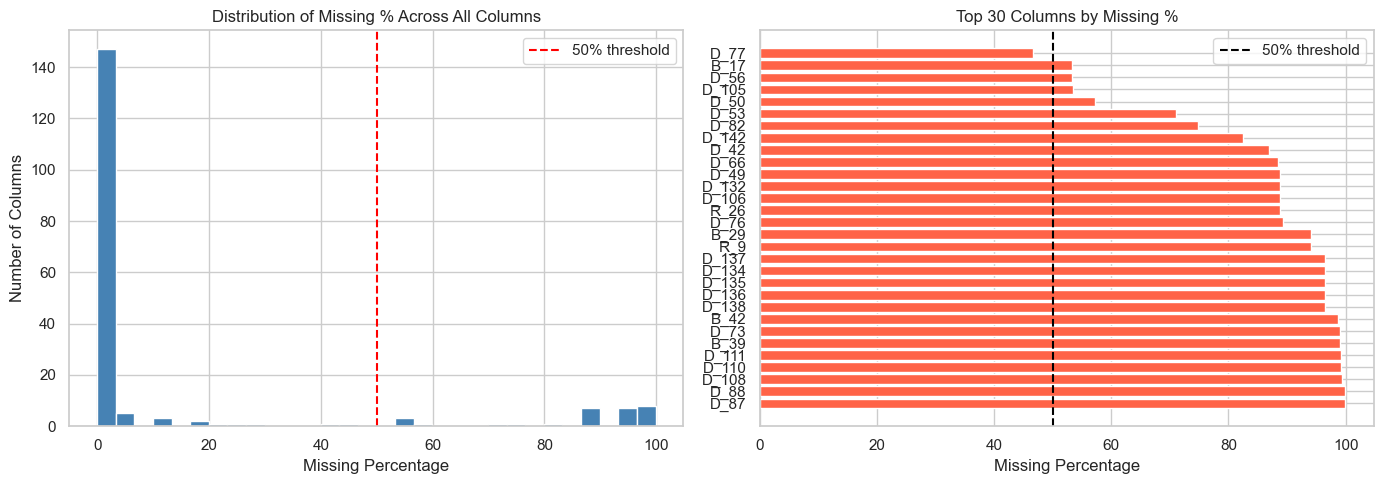

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(missing['missing_pct'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=50, color='red', linestyle='--', label='50% threshold')
axes[0].set_title('Distribution of Missing % Across All Columns')
axes[0].set_xlabel('Missing Percentage')
axes[0].set_ylabel('Number of Columns')
axes[0].legend()

top_missing = missing[missing['missing_pct'] > 0].head(30)
axes[1].barh(top_missing['column'], top_missing['missing_pct'], color='tomato')
axes[1].axvline(x=50, color='black', linestyle='--', label='50% threshold')
axes[1].set_title('Top 30 Columns by Missing %')
axes[1].set_xlabel('Missing Percentage')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
#dropping columnns with more than 50 pct missing values
cols_over_50pct=missing[missing['missing_pct']>50]['column'].tolist()

#also drop identifier columns-not features , carry no predictive value
identifier_cols=['customer_ID','S_2']

cols_to_drop=cols_over_50pct + identifier_cols
df_clean=df.drop(columns=cols_to_drop)

print(f'COlumns dropped due to >50 pct missing :{len(cols_over_50pct)}')
print(f'Identifier columns dropped:{identifier_cols}')
print(f'Total Columns dropped:{len(cols_to_drop)}')
print(f'\nShape before:{df.shape}')
print(f'Shape after:{df_clean.shape}')

COlumns dropped due to >50 pct missing :29
Identifier columns dropped:['customer_ID', 'S_2']
Total Columns dropped:31

Shape before:(458913, 191)
Shape after:(458913, 160)


In [11]:
remaining_numeric=[col for col in numeric_cols if col in df_clean.columns]
remaining_cat=[col for col in cat_cols if col in df_clean.columns]

for col in remaining_numeric:
    if df_clean[col].isnull().sum()>0:
        median_val=df_clean[col].median()
        df_clean[col]=df_clean[col].fillna(median_val)
        
print('Numeric imputation complete')

# categorical columns — impute with mode (most frequent value)
for col in remaining_cat:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)

total_missing_after = df_clean.isnull().sum().sum()
print(f'\nTotal missing values remaining: {total_missing_after}')


Numeric imputation complete

Total missing values remaining: 0


In [15]:
Clean_path='../data/amex_clean.parquet'

df_clean.to_parquet(Clean_path,index=False)

conn.close()

print("clean data saved")
print(f'Final shape:{df_clean.shape}')
print(f'Features remaining:{df_clean.shape[1]-1}')


clean data saved
Final shape:(458913, 160)
Features remaining:159
